## Interactive notebook to test GA optimisation of excitation transfer

## 1. Imports

In [66]:
from qtransfer.network.adjacency import random_adjacency
from qtransfer.network import Network, ControlSequence

from qgene.optimisation import  GeneticOptimiser
from qgene.operators import UniformCrossover, DiscreteMutation
from qgene.selection import UniformSelection
from qgene.individual import Individual

from qsim.state import DensityMatrix
import numpy as np
import random

## 2. Target

Setting network size and connections

In [67]:
n=6
p=0.7
target_adj = random_adjacency(n, p, seed = 112)

Configuring initial state

In [68]:

initial_node = 0
rho0 = np.zeros((n,n))

## Choose this for localised excitation
rho0[initial_node, initial_node] = 1

## Choose this for distributed excitation
#rho0 = np.outer(np.array([1/(n**0.5) for i in range(n)]), np.array([1/(n**0.5) for i in range(n)]))

rho0 = DensityMatrix(rho0)


Setting up sink and environmental couplings

In [69]:
sink_locations = [5]
sink_coupling_strengths = [1]

## Change this to alter the rate of dissipation
env_damping = [0.3 for i in range(n)]

Visualising the network structure - the last two nodes represent the sink and the environment

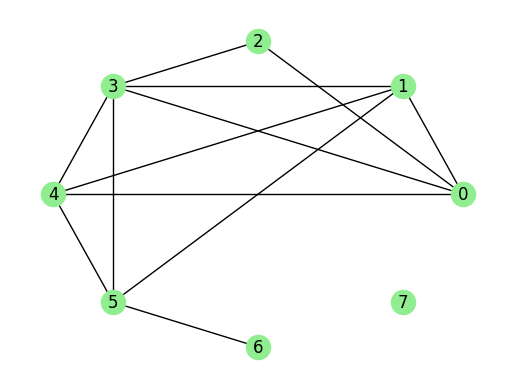

In [70]:
target_network = Network(target_adj, rho0=rho0, sink_coupling_strengths=sink_coupling_strengths, sink_locations=sink_locations, local_loss_strengths=env_damping)
d = target_network.diagram()

Network energy transfer of: 0.5553152364869899


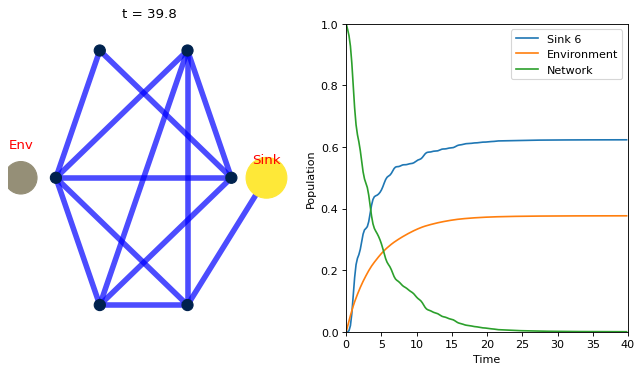

In [71]:
ts = 0.2
n_steps = 200
print(f'Network energy transfer of: {target_network.energy_transfer}')
target_network.animateEvolutionWithConnections(ts, n_steps)

## 3. Settings

Setting up dynamic control settings

In [97]:
# Define the times at which the Hamiltonian can be modified
control_times = [0, .5, 1, 1.5, 2]

In [98]:
# Selecting the adjacency matrix elements to provide control over, this setup is the full off-diagonal adjacency matrix
control_mask = np.zeros((n,n))
control_mask[np.tril_indices(n, k=0)] = 1
control_mask = (control_mask == 1)

In [99]:
vectorised_adj = target_adj[control_mask].flatten()

Configuring the discrete values that the control matrix elements can take, modify the spacing to np.linspace(0, 1, x) to allow for x discrete values

In [100]:
limits = [] 

for t in control_times:
    limits += [np.linspace(0, 1, 20) - x for x in vectorised_adj]

## 4. Initial Population

In [101]:
pop_size = 200

In [102]:
pop = [Individual(tuple(random.choice(lims) for lims in limits)) for i in range(pop_size)]


# 5. Optimiser

Configuring optimisation functions. Optimisation is always a maximisation procedure, uncomment net.control_cost to include the energetic cost of control operations

In [103]:
from multiprocess import Pool
from functools import partial

# 1. Pull the inner loop out into a standalone "pure" function
def _evaluate_single(p, control_times, n, control_mask, target_adj, rho0, sink_locations, sink_coupling_strengths, env_damping):
    if p.score is not None:
        return p.score
        
    control = ControlSequence.from_individual(control_times, p, n, control_mask)
    net = Network(
        A=target_adj, 
        rho0=rho0, 
        control=control, 
        sink_locations=sink_locations, 
        sink_coupling_strengths=sink_coupling_strengths, 
        local_loss_strengths=env_damping
    )
    return net.energy_transfer #- net.control_energy_cost

def score_func(pop: list[Individual]):
    # 2. Bundle the function with all your external simulation parameters
    eval_func = partial(
        _evaluate_single,
        control_times=control_times,
        n=n,
        control_mask=control_mask,
        target_adj=target_adj,
        rho0=rho0,
        sink_locations=sink_locations,
        sink_coupling_strengths=sink_coupling_strengths,
        env_damping=env_damping
    )
    
    # 3. Spin up the CPU cores using the multiprocess library
    with Pool() as pool:
        # This executes the bundled function across your population array in parallel
        results = pool.map(eval_func, pop)
        
    # 4. Reassign the calculated scores back to the original objects in the main thread
    for p, score in zip(pop, results):
        p.score = score

def score_func(pop: list[Individual]):
    for p in pop:
        if p.score is None:
            control = ControlSequence.from_individual(control_times, p, n, control_mask)
            net = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)
            p.score = net.energy_transfer - net.control_energy_cost

Genetic operator setup, modify p in DiscreteMutation to control mutation rate, pop_fraction to control how much of the population is used to generate new solutions

In [104]:
crossover = UniformCrossover()
mutation = DiscreteMutation(p = 0.1, vals=limits)
selection = UniformSelection(pop_fraction=0.25)

Run genetic optimiser, modify the retention parameter to increase or decrease the fraction of the old population that is retained each generation

In [105]:
g = GeneticOptimiser(pop, score_func=score_func, selection_func=selection, crossover_func=crossover, mutation_func=mutation, retention=0.02, verbose=1)

In [106]:
g.optimise(early_stopping=True)

Best: 0.7953 | Mean: 0.6698 | Div: 0.2577:  32%|███▏      | 32/100 [05:11<11:01,  9.73s/it]

Early stopping


Visualising optimal genetic algorithm solution

In [111]:
control = ControlSequence.from_individual(control_times, g.optimal_individual, n, control_mask)
net = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)

In [112]:
rho0.matrix

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [113]:
np.diag(control.operators[0]) - np.diag(control.operators[1])

array([-0.84210526+0.j,  0.10526316+0.j, -0.10526316+0.j,  0.68421053+0.j,
        0.68421053+0.j, -0.52631579+0.j])

Network energy transfer of: 0.7952634958248253
Increase in energy transfer of: 0.23994825933783537


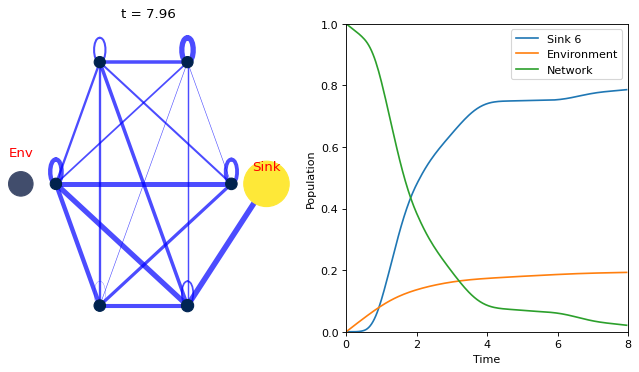

In [114]:
print(f'Network energy transfer of: {net.energy_transfer}')
print(f'Increase in energy transfer of: {net.energy_transfer - target_network.energy_transfer}')
net.animateEvolutionWithConnections(ts*0.2, n_steps)